# 02 — RFM + KMeans customer segmentation

We already have a rule-based segment label in `customer_rfm`. Here we refine it with KMeans on log-transformed RFM features, then compare clusters to the rule-based labels.

In [1]:
import sys
from pathlib import Path

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
ROOT = HERE if HERE.name != "notebooks" else HERE.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib  # noqa: E402

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import seaborn as sns  # noqa: E402
from sklearn.cluster import KMeans  # noqa: E402
from sklearn.metrics import silhouette_score  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

from olist.io import read_mart  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
INTERACTIVE = "ipykernel" in sys.modules


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    if not INTERACTIVE:
        plt.close(fig)

## Load the RFM mart

In [2]:
rfm = read_mart("customer_rfm")
n_before = len(rfm)
rfm = rfm.dropna(subset=["recency_days", "frequency", "monetary"]).reset_index(drop=True)
print(f"customers: {len(rfm):,}  (dropped {n_before - len(rfm)} rows with NaN R/F/M)")
print(rfm[["recency_days", "frequency", "monetary"]].describe().round(2))

customers: 94,983  (dropped 7 rows with NaN R/F/M)
       recency_days  frequency  monetary
count      94983.00   94983.00  94983.00
mean         244.33       1.03    165.67
std          152.98       0.21    226.73
min            1.00       1.00      9.59
25%          120.00       1.00     63.10
50%          225.00       1.00    107.90
75%          353.00       1.00    182.93
max          730.00      16.00  13664.08


Frequency and monetary are heavily right-skewed (most customers buy once for ~100 BRL). Log-transform both.

In [3]:
X = pd.DataFrame(
    {
        "recency_days": rfm["recency_days"],
        "log_frequency": np.log1p(rfm["frequency"]),
        "log_monetary": np.log1p(rfm["monetary"]),
    }
)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

## Pick `k` — elbow + silhouette

In [4]:
ks = list(range(2, 9))
inertias = []
silhouettes = []
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=min(10_000, len(X_scaled)), replace=False)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))
    print(f"k={k}  inertia={km.inertia_:>12,.0f}  silhouette={silhouettes[-1]:.4f}")

k=2  inertia=     193,499  silhouette=0.7019


k=3  inertia=     128,520  silhouette=0.3570


k=4  inertia=      87,328  silhouette=0.3659


k=5  inertia=      71,631  silhouette=0.3575


k=6  inertia=      60,389  silhouette=0.3491


k=7  inertia=      51,663  silhouette=0.3652


k=8  inertia=      45,998  silhouette=0.3538


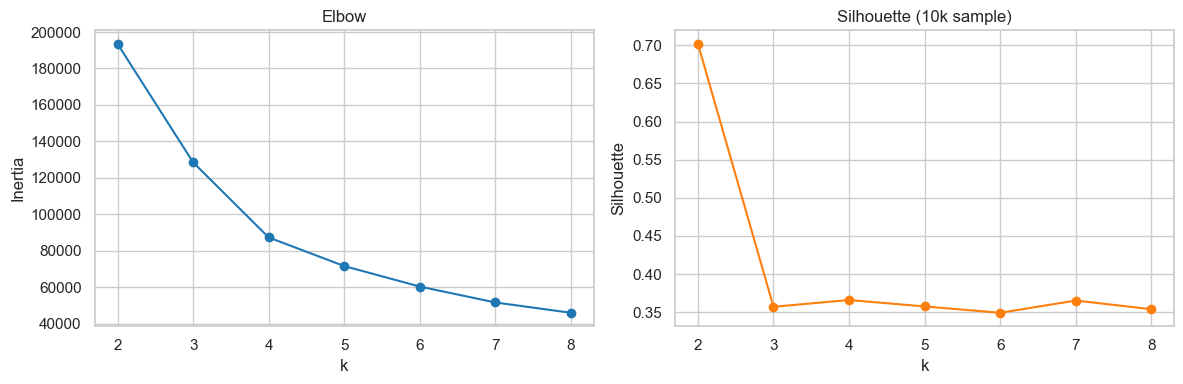

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker="o", color="#1f77b4")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow")

axes[1].plot(ks, silhouettes, marker="o", color="#ff7f0e")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].set_title("Silhouette (10k sample)")
plt.tight_layout()
save(fig, "06_kmeans_elbow")

Pick **k = 4** as a portfolio-friendly default — elbow flattens after k=4, silhouette stays comparable.

In [6]:
K = 4
final_km = KMeans(n_clusters=K, random_state=42, n_init=20)
rfm["kmeans_cluster"] = final_km.fit_predict(X_scaled)

# Sort clusters by mean monetary for stable labeling across re-runs
order = (
    rfm.groupby("kmeans_cluster")["monetary"].mean().sort_values(ascending=False).index.tolist()
)
label_map = {old: f"C{rank}" for rank, old in enumerate(order)}
rfm["cluster"] = rfm["kmeans_cluster"].map(label_map)

profile = (
    rfm.groupby("cluster")
    .agg(
        n=("customer_unique_id", "count"),
        recency_mean=("recency_days", "mean"),
        recency_median=("recency_days", "median"),
        frequency_mean=("frequency", "mean"),
        monetary_mean=("monetary", "mean"),
        monetary_median=("monetary", "median"),
    )
    .round(2)
    .sort_index()
)
print("Cluster profile (sorted by mean monetary value desc):")
print(profile)

Cluster profile (sorted by mean monetary value desc):
             n  recency_mean  recency_median  frequency_mean  monetary_mean  \
cluster                                                                       
C0       28387        179.86           176.0            1.00         318.72   
C1        2888        227.38           206.5            2.11         308.26   
C2       27450        432.36           425.0            1.00         119.92   
C3       36258        153.81           153.0            1.00          69.12   

         monetary_median  
cluster                   
C0                210.56  
C1                225.53  
C2                 98.14  
C3                 66.03  


## Cross-tab with the rule-based labels

In [7]:
xtab = pd.crosstab(rfm["cluster"], rfm["rfm_segment_label"])
xtab_pct = (xtab.T / xtab.sum(axis=1)).T * 100
print("\nCluster x rule-based label (counts):")
print(xtab)
print("\nCluster x rule-based label (% of cluster):")
print(xtab_pct.round(1))


Cluster x rule-based label (counts):
rfm_segment_label  At Risk  Champions   Lost  Loyal   New  Other
cluster                                                         
C0                    3378       5499   2347   7884  6130   3149
C1                    1030       1006      0    747     0    105
C2                   16095          0  11321     21     0     13
C3                    2191         30   1629   5981  8985  17442

Cluster x rule-based label (% of cluster):
rfm_segment_label  At Risk  Champions  Lost  Loyal   New  Other
cluster                                                        
C0                    11.9       19.4   8.3   27.8  21.6   11.1
C1                    35.7       34.8   0.0   25.9   0.0    3.6
C2                    58.6        0.0  41.2    0.1   0.0    0.0
C3                     6.0        0.1   4.5   16.5  24.8   48.1


Most KMeans clusters correspond loosely to a rule-based label but with smoother boundaries. The KMeans view is preferred for downstream targeting because it doesn't depend on hand-picked R/F/M thresholds.

## Visualize clusters in 2D

Two scatter views: (recency, log_frequency) and (log_frequency, log_monetary). With ~95k points, draw a 5k sample.

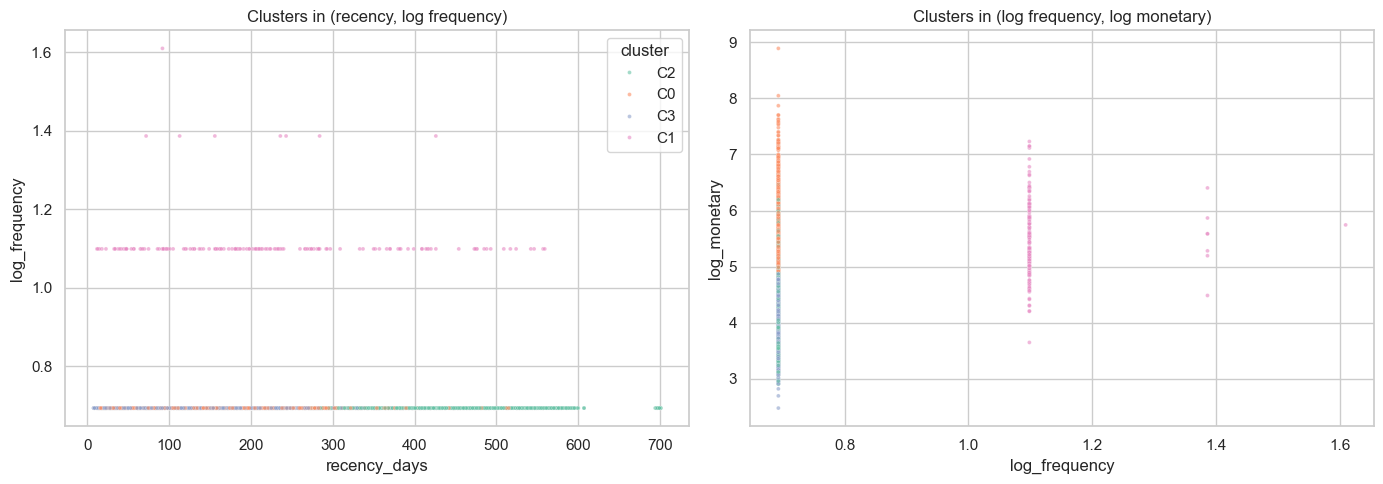

In [8]:
plot_df = rfm.sample(5_000, random_state=42).copy()
plot_df["log_frequency"] = np.log1p(plot_df["frequency"])
plot_df["log_monetary"] = np.log1p(plot_df["monetary"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("Set2", K)
sns.scatterplot(
    data=plot_df,
    x="recency_days",
    y="log_frequency",
    hue="cluster",
    palette=palette,
    s=8,
    alpha=0.6,
    ax=axes[0],
)
axes[0].set_title("Clusters in (recency, log frequency)")

sns.scatterplot(
    data=plot_df,
    x="log_frequency",
    y="log_monetary",
    hue="cluster",
    palette=palette,
    s=8,
    alpha=0.6,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Clusters in (log frequency, log monetary)")
plt.tight_layout()
save(fig, "07_kmeans_clusters_2d")

## Save cluster assignments

In [9]:
OUT_DIR = ROOT / "data" / "exports"
OUT_DIR.mkdir(parents=True, exist_ok=True)
rfm[["customer_unique_id", "cluster", "kmeans_cluster"]].to_csv(
    OUT_DIR / "customer_clusters.csv", index=False
)
print(f"Saved {len(rfm):,} cluster assignments -> data/exports/customer_clusters.csv")

Saved 94,983 cluster assignments -> data/exports/customer_clusters.csv


## Next step

In `03_repeat_purchase.py` we model the binary outcome "did this customer buy again within 180 days of first purchase".